## **1. Import Libraries**

In [ ]:
import numpy as np
import pandas as pd

# **2. Load Data**

In [ ]:
df = pd.read_csv('Unemployment in India.csv')
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


## Use Python for data cleaning, exploration, and visualization of unemployment trends.

# 3) **Data Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
print(df.shape)

(768, 7)


In [ ]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
# Missing value percentage calculate
total_rows = df.shape[0]
missing_values = df.isnull().sum().max()  # ya specific column bhi le sakte ho

percentage = (missing_values / total_rows) * 100

print("Missing Percentage:", percentage)

Missing Percentage: 3.6458333333333335


In [ ]:
# Missing value drop because its <5%
df.dropna(inplace=True)

In [ ]:
print(df.shape)

(740, 7)


In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
# Clean column names ' Estimated Unemployment Rate (%)' into 'Estimated Unemployment Rate (%)'
df.columns = df.columns.str.strip()


In [ ]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
# Convert Date
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
df['Date'].info()

<class 'pandas.core.series.Series'>
Index: 740 entries, 0 to 753
Series name: Date
Non-Null Count  Dtype         
--------------  -----         
740 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 11.6 KB


● Analyze unemployment rate data representing unemployed people percentage.


# **4. Basic Exploration**

In [ ]:
df['Estimated Unemployment Rate (%)'].describe()

,Estimated Unemployment Rate (%)
count,740.000000
mean,11.787946
std,10.721298
min,0.000000
25%,4.657500
50%,8.350000
75%,15.887500
max,76.740000


In [ ]:
# Average unemployment rate
print("Average Unemployment Rate (%):", df['Estimated Unemployment Rate (%)'].mean())

Average Unemployment Rate (%): 11.787945945945946


# **5)Visualization**

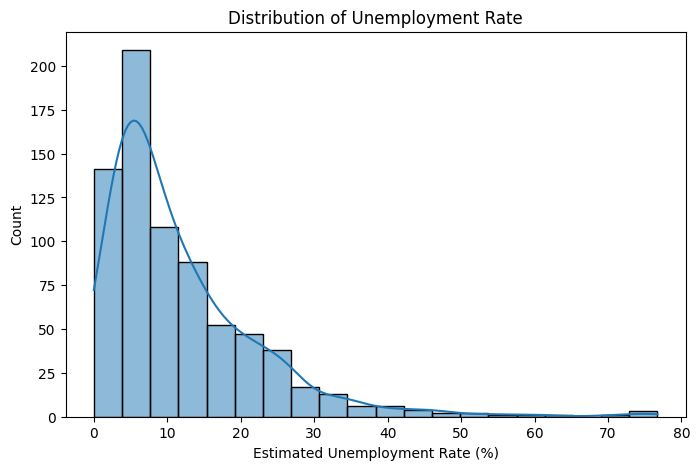

In [ ]:
# Distribution of Unemployment Rate
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['Estimated Unemployment Rate (%)'], bins=20, kde=True)
plt.title("Distribution of Unemployment Rate")
plt.show()

**1. Overall Trend**

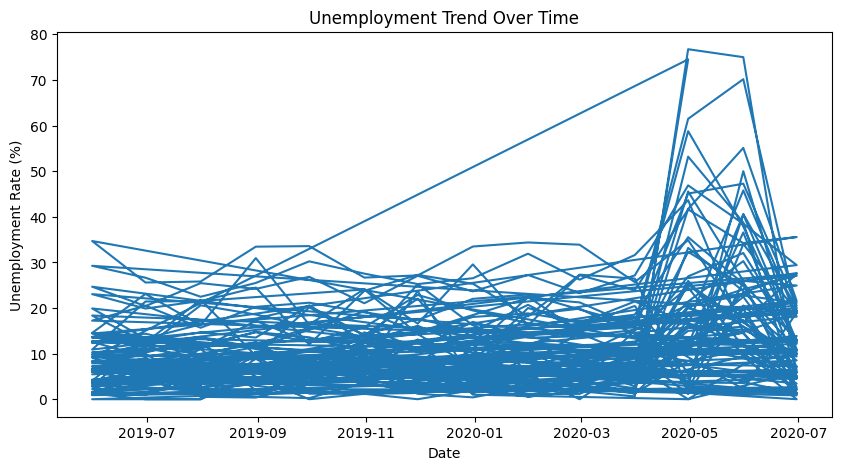

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Estimated Unemployment Rate (%)'])
plt.title("Unemployment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.show()
# Insight: Trend up-down hota hai (fluctuation)
# Data fluctuate karta hai (stable nahi hai)

Investigate the impact of Covid-19 on unemployment rates.

**2. COVID-19 Impact Analysis**

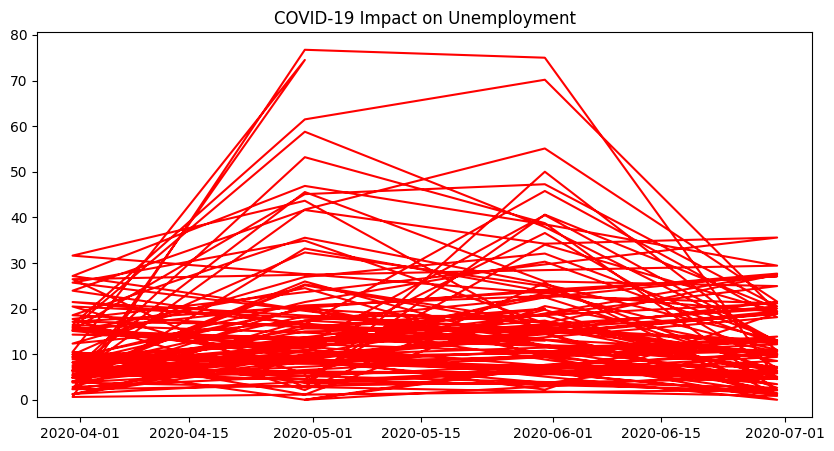

In [ ]:
covid = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(10,5))
plt.plot(covid['Date'], covid['Estimated Unemployment Rate (%)'], color='red')
plt.title("COVID-19 Impact on Unemployment")
plt.show()
# Insight:

# March 2020 ke baad sudden spike 📈
# Lockdown effect

dentify key patterns or seasonal trends in the data.

### ***3) Region-wise Analysis***

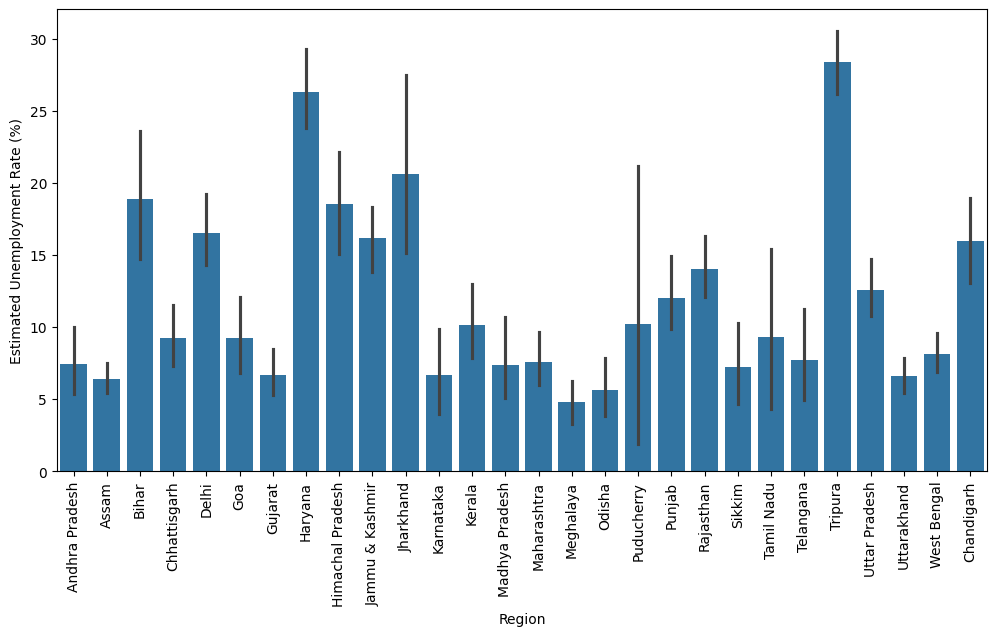

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.show()

# Insight:
# Har region me unemployment different hai

**4. Seasonal Trends**

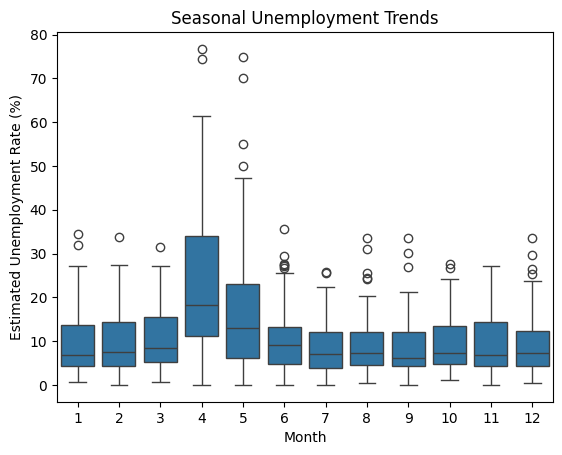

In [ ]:
df['Month'] = df['Date'].dt.month

sns.boxplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Seasonal Unemployment Trends")
plt.show()
# Insight:
# Kuch months me unemployment consistently high hota hai

**Rural vs Urban Unemployment**

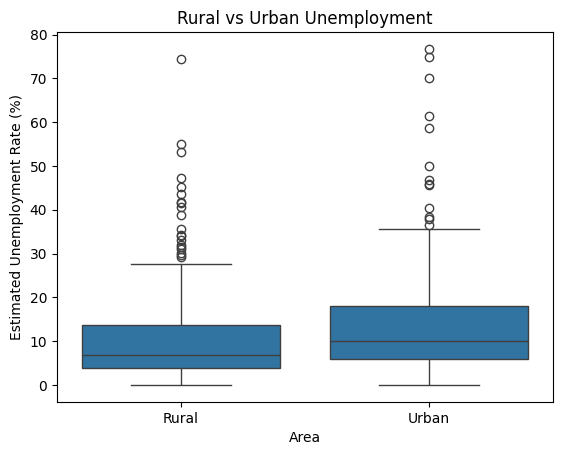

In [ ]:
sns.boxplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Rural vs Urban Unemployment")
plt.show()
# Insight:
# Urban areas me unemployment zyada hota hai (usually)

**Employment vs Unemployment**

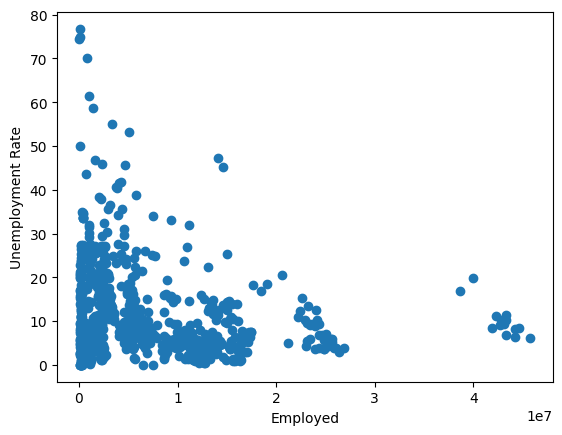

In [ ]:
plt.scatter(df['Estimated Employed'], df['Estimated Unemployment Rate (%)'])
plt.xlabel("Employed")
plt.ylabel("Unemployment Rate")
plt.show()
# Insight:
# Jahan employment zyada hoti hai, wahan unemployment kam hoti hai